# 03 · AdaptCNLM — Symmetry-Based Qubit Reduction

Quantum annealers have a **limited, expensive** qubit budget and a fixed hardware graph
(Chimera / Pegasus). **AdaptCNLM** shrinks the number of logical qubits needed to encode a
SAT instance by exploiting **structure and symmetry**, then (optionally) embeds the smaller
problem onto real D-Wave topologies.

It offers three encoders, trading qubit count against fidelity:

| Encoder | Idea | Qubits |
|---------|------|--------|
| `OrbitBasedEncoder` | one qubit per symmetry **orbit** (baseline / "non-reduced") | most |
| `CliqueBasedEncoder` | group variables by **clique** structure | fewer |
| `ClusterBasedEncoder` | greedy **clustering** of variables | fewest |

Pipeline: **load → detect symmetry → encode → solve → bit-flip polish → (embed)**.

This notebook walks the whole pipeline on a small symmetric instance, with comparison plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import pycnlm
from pycnlm import parse_cnf_file
from pycnlm.adapt import (
    SymmetryDetector, OrbitBasedEncoder, CliqueBasedEncoder, ClusterBasedEncoder,
)

# Optional hardware-embedding deps
try:
    import dwave_networkx, minorminer  # noqa: F401
    DWAVE = True
except Exception:
    DWAVE = False

DATA = Path("data")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
COLORS = {"orbit": "#e74c3c", "clique": "#f39c12", "cluster": "#2ecc71"}
print("pycnlm", pycnlm.__version__, "| D-Wave embedding deps:", "available" if DWAVE else "not installed")

pycnlm 0.1.0 | D-Wave embedding deps: not installed


## 1. Load the SAT instance

We use a 9-variable instance built from three *exactly-one* groups plus cross-links — it has exploitable structure.

In [2]:
sat = parse_cnf_file(DATA / "sample_symmetric.cnf")
print(f"variables : {sat.num_vars}")
print(f"clauses   : {sat.num_clauses}")
print("\nclauses (DIMACS literals):")
for i, cl in enumerate(sat.clauses, 1):
    print(f"  c{i:2d}: {cl}")

Loaded CNF file: data/sample_symmetric.cnf
  Variables: 9
  Clauses: 14
variables : 9
clauses   : 14

clauses (DIMACS literals):
  c 1: [1, 2, 3]
  c 2: [-1, -2]
  c 3: [-1, -3]
  c 4: [-2, -3]
  c 5: [4, 5, 6]
  c 6: [-4, -5]
  c 7: [-4, -6]
  c 8: [-5, -6]
  c 9: [7, 8, 9]
  c10: [-7, -8]
  c11: [-7, -9]
  c12: [-8, -9]
  c13: [1, 4, 7]
  c14: [2, 5, 8]


## 2. Symmetry detection → orbits

`SymmetryDetector.find_orbits()` partitions variables into **orbits** — sets that the
instance's symmetry group can permute among themselves. Orbits are the basis for the
non-reduced (orbit) encoding.

In [3]:
sym = SymmetryDetector(sat)
orbits = sym.find_orbits()
print(f"{sat.num_vars} variables -> {len(orbits)} orbits")
for i, orb in enumerate(orbits):
    members = sorted(v + 1 for v in orb)   # back to 1-based DIMACS var ids
    tag = "  (non-trivial)" if len(orb) > 1 else ""
    print(f"  orbit {i}: {members}{tag}")

9 variables -> 9 orbits
  orbit 0: [1]
  orbit 1: [2]
  orbit 2: [3]
  orbit 3: [4]
  orbit 4: [5]
  orbit 5: [6]
  orbit 6: [7]
  orbit 7: [8]
  orbit 8: [9]


## 3. Encode with all three strategies and compare qubit counts

Each encoder's `allocate_qubits()` returns `(qubit_map, n_qubits)`. We build all three and
compare how aggressively they compress the 9 logical variables.

In [4]:
confidence = 1.0   # ε in [0,1]: strength of clause-satisfaction signal (1.0 = full logic)

encoders = {
    "orbit":   OrbitBasedEncoder(sat, orbits, confidence=confidence),
    "clique":  CliqueBasedEncoder(sat, orbits, confidence=confidence),
    "cluster": ClusterBasedEncoder(sat, orbits, confidence=confidence),
}

n_qubits = {}
for name, enc in encoders.items():
    _, nq = enc.allocate_qubits()
    n_qubits[name] = nq

base = sat.num_vars
print(f"\n{'encoder':10s} | {'qubits':>6s} | {'reduction':>9s}")
print("-"*32)
for name, nq in n_qubits.items():
    print(f"{name:10s} | {nq:6d} | {(1-nq/base)*100:7.1f}%")

Non-Reduced Encoding: 9 qubits (1 per orbit)
Clique-Based Encoding: 6 qubits from 3 cliques
Cluster-Based Encoding: 4 qubits from 1 clusters

encoder    | qubits | reduction
--------------------------------
orbit      |      9 |     0.0%
clique     |      6 |    33.3%
cluster    |      4 |    55.6%


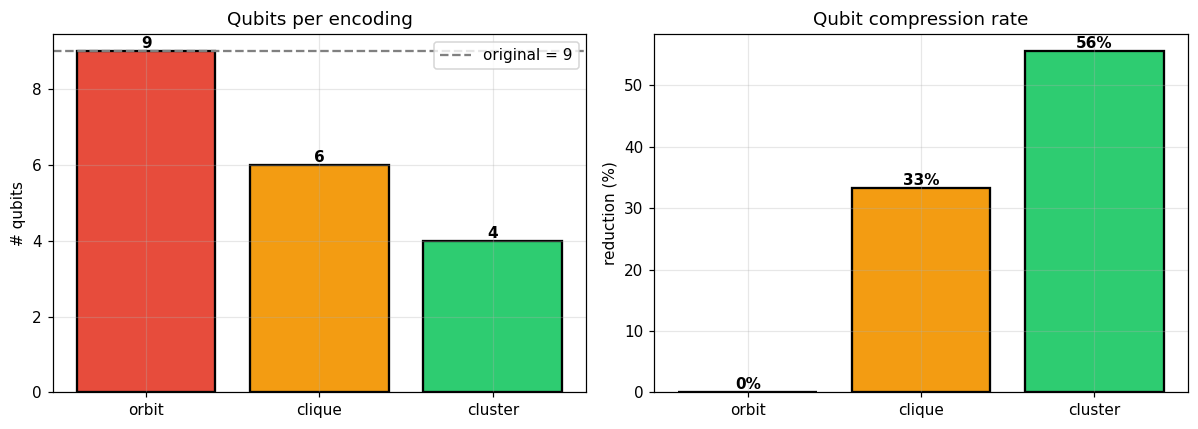

In [5]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(11, 4))
names = list(n_qubits)
vals = [n_qubits[n] for n in names]
cols = [COLORS[n] for n in names]

bars = axL.bar(names, vals, color=cols, edgecolor="k", lw=1.5)
axL.axhline(base, color="gray", ls="--", lw=1.5, label=f"original = {base}")
for b, v in zip(bars, vals):
    axL.text(b.get_x()+b.get_width()/2, b.get_height(), str(v), ha="center", va="bottom", fontweight="bold")
axL.set_title("Qubits per encoding"); axL.set_ylabel("# qubits"); axL.legend()

red = [(1 - n_qubits[n]/base)*100 for n in names]
bars = axR.bar(names, red, color=cols, edgecolor="k", lw=1.5)
for b, v in zip(bars, red):
    axR.text(b.get_x()+b.get_width()/2, b.get_height(), f"{v:.0f}%", ha="center", va="bottom", fontweight="bold")
axR.set_title("Qubit compression rate"); axR.set_ylabel("reduction (%)")
plt.tight_layout(); plt.show()

## 4. Solve with each encoding

The encoders ship a classical fall-back solver (`solve`) so the tutorial runs without any
quantum SDK. We solve with each and score the result against the original clauses via
`sat.evaluate(assignment) -> (is_valid, unsatisfied_clause_ids)`.

> A more compressed encoding may occasionally miss a few clauses — that lossy-vs-cheap
> trade-off is the whole point. We fix it in the next step with bit-flip polishing.

In [6]:
solve_scores = {}
for name, enc in encoders.items():
    assignment, energy = enc.solve(steps=8000, restarts=8)
    valid, unsat = sat.evaluate(assignment)
    score = (1 - len(unsat)/sat.num_clauses) * 100
    solve_scores[name] = score
    print(f"{name:10s}: SAT score {score:6.2f}%  "
          f"({sat.num_clauses-len(unsat)}/{sat.num_clauses} clauses)  "
          f"energy={energy:.3f}  valid={valid}")

orbit     : SAT score 100.00%  (14/14 clauses)  energy=0.000  valid=True
clique    : SAT score 100.00%  (14/14 clauses)  energy=0.000  valid=True


cluster   : SAT score  78.57%  (11/14 clauses)  energy=2.154  valid=False


## 5. Bit-flip post-processing

`bitflip_search` is a structure-aware local search that flips whole orbits / cliques /
clusters at once. It returns `(assignment, sat_history, unsat_history)` where `sat_history`
is the **best SAT score (%) per iteration** — ideal for a convergence plot.

In [7]:
histories = {}
for name, enc in encoders.items():
    bf_assign, sat_hist, unsat_hist = enc.bitflip_search(
        num_iterations=4000, flip_prob=0.3, flip_type=name,
    )
    histories[name] = np.asarray(sat_hist)
    valid, unsat = sat.evaluate(bf_assign)
    final = (1 - len(unsat)/sat.num_clauses) * 100
    print(f"{name:10s}: bitflip best {max(sat_hist):6.2f}%  final {final:6.2f}%  "
          f"mean {np.mean(sat_hist):6.2f}%")

orbit     : bitflip best 100.00%  final 100.00%  mean  79.81%
clique    : bitflip best 100.00%  final 100.00%  mean  79.11%
cluster   : bitflip best 100.00%  final 100.00%  mean  79.74%


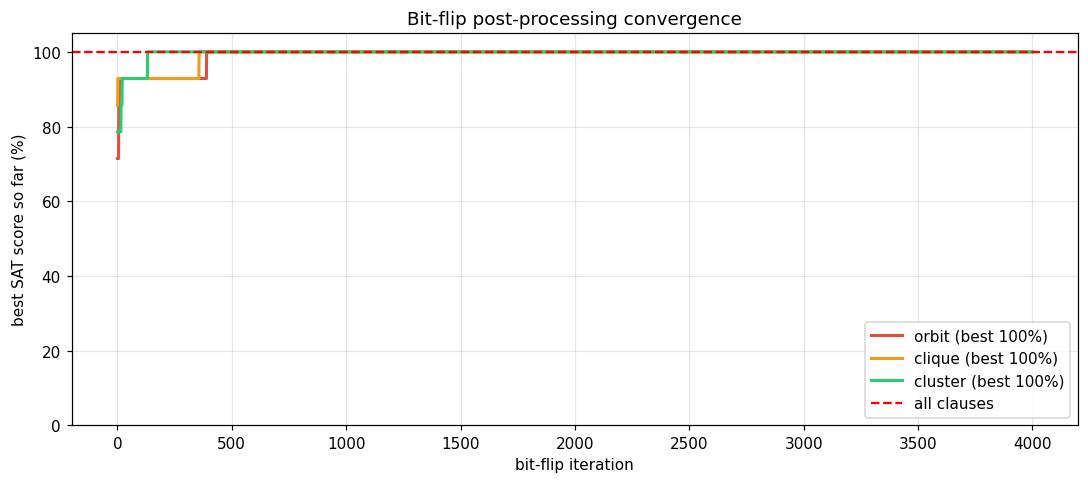

In [8]:
# Running-best convergence curves
plt.figure(figsize=(10, 4.5))
for name, h in histories.items():
    running_best = np.maximum.accumulate(h)
    plt.plot(running_best, color=COLORS[name], lw=2, label=f"{name} (best {running_best[-1]:.0f}%)")
plt.axhline(100, color="red", ls="--", lw=1.5, label="all clauses")
plt.ylim(0, 105)
plt.xlabel("bit-flip iteration"); plt.ylabel("best SAT score so far (%)")
plt.title("Bit-flip post-processing convergence")
plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## 6. Adaptive-confidence solving

`solve_adaptive_confidence` anneals the confidence ε on the fly, recording an
`energy_history` and `confidence_history`. It returns `(assignment, energy, stats)`.

In [9]:
enc = encoders["cluster"]
assignment, energy, stats = enc.solve_adaptive_confidence(
    steps=6000, initial_conf=0.5, verbose=False,
)
print("improvements :", stats["improvements"])
print("stagnations  :", stats["stagnation"])
print("final energy :", round(stats["final_energy"], 4))
print("final score  :", round(stats["final_sat_score"], 2), "%")

improvements : 2
stagnations  : 5
final energy : 1.0775
final score  : 71.43 %


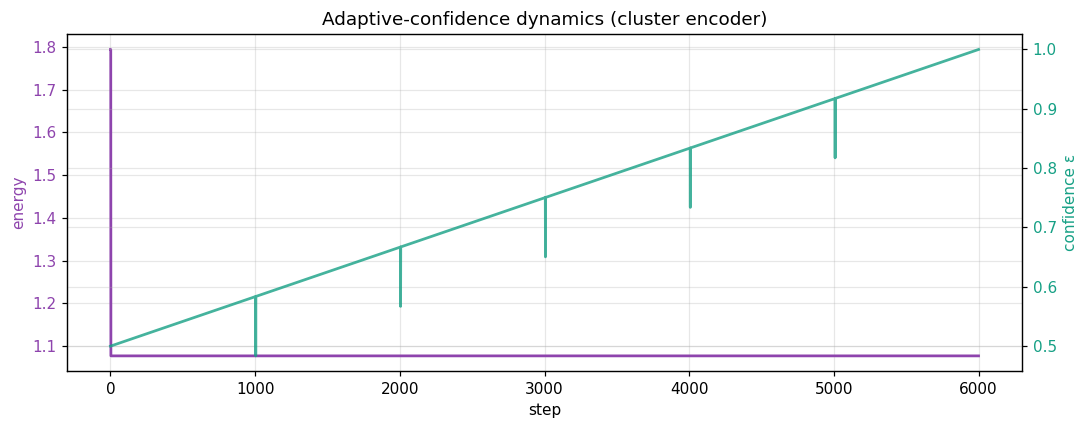

In [10]:
e_hist = np.asarray(stats["energy_history"])
c_hist = np.asarray(stats["confidence_history"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(e_hist, color="#8e44ad", lw=1.8, label="energy")
ax.set_xlabel("step"); ax.set_ylabel("energy", color="#8e44ad")
ax.tick_params(axis="y", labelcolor="#8e44ad")
ax2 = ax.twinx()
ax2.plot(c_hist, color="#16a085", lw=1.8, alpha=0.8, label="confidence ε")
ax2.set_ylabel("confidence ε", color="#16a085")
ax2.tick_params(axis="y", labelcolor="#16a085")
ax.set_title("Adaptive-confidence dynamics (cluster encoder)")
plt.tight_layout(); plt.show()

## 7. Putting it together — final scoreboard

In [11]:
print(f"{'encoder':10s} | {'qubits':>6s} | {'solve%':>7s} | {'bitflip best%':>13s}")
print("-"*46)
for name in encoders:
    print(f"{name:10s} | {n_qubits[name]:6d} | {solve_scores[name]:7.1f} | "
          f"{histories[name].max():13.1f}")

encoder    | qubits |  solve% | bitflip best%
----------------------------------------------
orbit      |      9 |   100.0 |         100.0
clique     |      6 |   100.0 |         100.0
cluster    |      4 |    78.6 |         100.0


## 8. (Optional) Embedding onto a D-Wave topology

If `dwave-networkx` + `minorminer` are installed, each encoder can embed its QUBO onto a real
hardware graph via `embed_to_dwave_topology(...)`. This cell is **guarded** so the notebook
still runs without the quantum SDK.

In [12]:
if DWAVE:
    import tempfile, os
    out = tempfile.mkdtemp(prefix="adaptcnlm_")
    print("embedding into Pegasus topology...\n")
    for name, enc in encoders.items():
        try:
            emb = enc.embed_to_dwave_topology(topology="pegasus", output_dir=out, method_name=name)
            if emb.get("success"):
                print(f"  {name:10s}: ✓ embedded  max chain length = {emb.get('max_chain_length','?')}")
            else:
                print(f"  {name:10s}: ✗ embedding failed")
        except Exception as e:
            print(f"  {name:10s}: error — {e}")
else:
    print("D-Wave embedding deps not installed — skipping.")
    print('Install with:  pip install "pycnlm[dwave]"   (dwave-networkx, minorminer, dimod, neal)')

D-Wave embedding deps not installed — skipping.
Install with:  pip install "pycnlm[dwave]"   (dwave-networkx, minorminer, dimod, neal)


## Summary

* `SymmetryDetector.find_orbits()` exposes the structure AdaptCNLM exploits.
* Three encoders (`Orbit` / `Clique` / `Cluster`) trade qubit count vs. fidelity; here
  9 variables compressed to **9 / 6 / 4** qubits.
* Each encoder has a classical `solve()` so you can experiment without quantum hardware.
* `bitflip_search` polishes a compressed solution back up to 100% satisfaction.
* `solve_adaptive_confidence` anneals ε and exposes energy/confidence histories.
* With the `[dwave]` extra, `embed_to_dwave_topology()` maps the reduced problem onto
  Chimera / Pegasus.

You've now toured all three pillars of `pycnlm`. See the `scripts/` folder for the full-scale
batch drivers and benchmarks. 🚀